# Vibroacustica in pyCAFE — selezione dei domini

Questo notebook mostra come, da una mesh conforme unica (fluido 3D + piastra
sulla faccia), si arriva a **due domini separati** — acustico e strutturale —
e ai dati di interfaccia su cui si integra la matrice di accoppiamento.

**Stato dei blocchi**

| Blocco | Stato |
|---|---|
| Elemento acustico HEXA8 (`CHEXA8`) | validato (<1% vs cavità analitica) |
| Shell strutturale (`CQUAD4F`, 6 DOF/nodo) | validato (piastra CCCC, ~0.4% su mesh grezza) |
| Riconoscimento domini da physical groups | `pycafe.build_matrices.domains` |
| Pipeline `prepare_vibroacoustic_system` | due domini + interfaccia + coupling |
| Matrici di coupling `Kc`, `Mc` | `pycafe.build_matrices.coupling` |
| Solver del sistema accoppiato non simmetrico | `pycafe.solver.solver_vibroacoustic` |
| PML | **da fare** |

**Qui le due analisi modali restano volutamente disaccoppiate**: cavità rigida
da una parte, piastra incastrata dall'altra, ciascuna col solver simmetrico
reale (ARPACK shift-invert). È il passaggio che serve per validare gli elementi
uno per uno, prima di mescolarli.

Il **problema accoppiato** sulla stessa geometria — con `Kc`, i modi accoppiati,
il confronto S-S-S-S contro C-C-C-C e la risposta forzata — sta nel notebook
[`vibroacoustic_box_plate.ipynb`](vibroacoustic_box_plate.ipynb).

## 1. Mesh e physical groups

La mesh `coupling_geometry/box_plate.msh` è generata da
`make_box_plate_mesh.py`: scatola 0.8 × 0.6 × 0.5 m riempita di esaedri,
con la faccia superiore z = Lz marcata come piastra.

Convenzione dei nomi (è il contratto su cui lavora il modulo):

- `fluid` — dominio acustico (`fluid`, `acoustic`, o `domain` per mesh 2D legacy)
- `plate` — dominio strutturale (`plate`, `structure`, `shell`)
- `plate_clamp` — nodi incastrati della struttura (`plate_clamp`, `clamp`, `fixed`)
- `rigid_walls` — pareti rigide (Neumann omogeneo: nessuna azione, è il default)

In [1]:
import pathlib
import sys

import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse.linalg import eigsh

sys.path.insert(0, str(pathlib.Path.cwd().parent))

import pycafe
from pycafe.build_matrices.domains import identify_domains
from pycafe.build_matrices.element_registry import ELEMENT_TYPES
from pycafe.solver.solver_modale import solve_modal_acoustic_reduced

MESH = pathlib.Path.cwd().parent / "coupling_geometry" / "box_plate.msh"

# Geometria (deve combaciare con make_box_plate_mesh.py)
LX, LY, LZ = 0.8, 0.6, 0.5
# Fluido: aria
RHO0, C0 = 1.204, 343.0
# Piastra: acciaio 2 mm
T, RHO_S, E, NU = 0.002, 7800.0, 210e9, 0.3

nodes, elements, boundaries, groups = pycafe.load_mesh_with_groups(str(MESH))
print(f"nodi: {nodes.shape[0]}")
for name, g in groups.items():
    types = {k: v.shape[0] for k, v in g["elements"].items()}
    print(f"  {name:<12} dim={g['dim']}  {types}  nodi={len(g['nodes'])}")

Info    : Reading '/Users/danielefabbri/Desktop/pycafe_new/coupling_geometry/box_plate.msh'...
Info    : 27 entities
Info    : 378 nodes
Info    : 504 elements
Info    : Done reading '/Users/danielefabbri/Desktop/pycafe_new/coupling_geometry/box_plate.msh'
→ Line 2          | Dim: 1 | Order: 1 | Nodes/Elem: 2 | Count: 28
→ Quadrilateral 4 | Dim: 2 | Order: 1 | Nodes/Elem: 4 | Count: 236
→ Hexahedron 8    | Dim: 3 | Order: 1 | Nodes/Elem: 8 | Count: 240
nodi: 378
  plate_clamp  dim=1  {'Line 2': 28}  nodi=28
  plate        dim=2  {'Quadrilateral 4': 48}  nodi=63
  rigid_walls  dim=2  {'Quadrilateral 4': 188}  nodi=203
  fluid        dim=3  {'Hexahedron 8': 240}  nodi=378


Da notare: `plate` e `rigid_walls` contengono **entrambi** elementi
`Quadrilateral 4`. Nel dizionario globale `elements` finiscono nello stesso
array e non sono distinguibili — è proprio per questo che i physical groups
sono l'informazione autorevole sui domini.

In [2]:
print("Quadrilateri nel dizionario globale:",
      elements["Quadrilateral 4"].shape[0])
print("  di cui piastra:    ", groups["plate"]["elements"]["Quadrilateral 4"].shape[0])
print("  di cui pareti rigide:", groups["rigid_walls"]["elements"]["Quadrilateral 4"].shape[0])

Quadrilateri nel dizionario globale: 236
  di cui piastra:     48
  di cui pareti rigide: 188


## 2. `identify_domains` — dal nome del gruppo all'elemento

`identify_domains` fa il match fra i tipi di elemento presenti nel gruppo e il
**registro elementi**, filtrando per campo fisico (`acoustic` / `structural`) e
scegliendo, a parità di match, l'elemento di dimensione più alta.

In [3]:
print(f"{'chiave':<10} {'campo':<11} {'dim':<4} {'nodi':<5} {'DOF/nodo':<9} gmsh")
for key, spec in ELEMENT_TYPES.items():
    print(f"{key:<10} {spec.field:<11} {spec.dim:<4} {spec.n_nodes:<5} "
          f"{spec.dofs_per_node:<9} {spec.gmsh_names}")

chiave     campo       dim  nodi  DOF/nodo  gmsh
CQUAD4     acoustic    2    4     1         ('Quadrilateral 4', 'Quadrangle 4')
CQUAD8     acoustic    2    8     1         ('Quadrilateral 8', 'Quadrangle 8')
CHEXA8     acoustic    3    8     1         ('Hexahedron 8',)
CQUAD4F    structural  2    4     6         ('Quadrilateral 4', 'Quadrangle 4')


In [4]:
domains = identify_domains(groups)

for role, d in domains.items():
    print(f"{role:<10} <- group '{d['group']}'")
    print(f"           elem_type = {d['elem_type']}  "
          f"({d['conn0'].shape[0]} elementi, {len(d['nodes'])} nodi)")
    print(f"           conn0 0-based, prima riga: {d['conn0'][0]}")

fluid      <- group 'fluid'
           elem_type = CHEXA8  (240 elementi, 378 nodi)
           conn0 0-based, prima riga: [  0   8  72  31  56 142 238 234]
structure  <- group 'plate'
           elem_type = CQUAD4F  (48 elementi, 63 nodi)
           conn0 0-based, prima riga: [  4  32 107  55]


`conn0` è la connettività **0-based** già convertita: la mesh Gmsh è 1-based,
la conversione avviene qui una volta sola e a valle si lavora sempre 0-based.

`rigid_walls` non compare fra i domini: è una condizione al contorno
(Neumann omogeneo = parete rigida), che nella formulazione in pressione non
richiede alcun termine — è il comportamento naturale se non si fa nulla.

## 3. Visualizzazione dei due domini

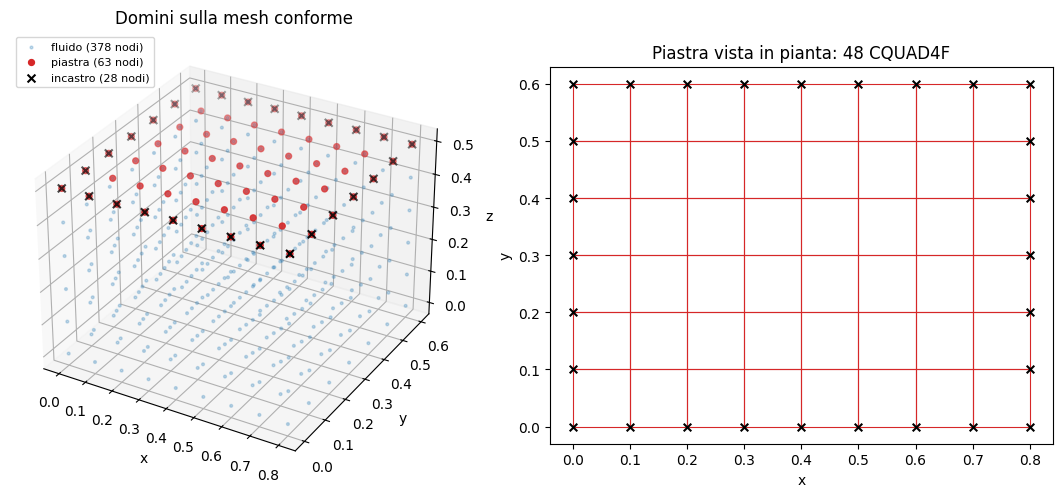

In [5]:
fluid_nodes0 = np.asarray(domains["fluid"]["nodes"], dtype=int) - 1
plate_nodes0 = np.asarray(domains["structure"]["nodes"], dtype=int) - 1
clamp_nodes0 = np.asarray(groups["plate_clamp"]["nodes"], dtype=int) - 1

fig = plt.figure(figsize=(11, 5))

ax = fig.add_subplot(121, projection="3d")
ax.scatter(*nodes[fluid_nodes0].T, s=4, c="tab:blue", alpha=0.25,
           label=f"fluido ({len(fluid_nodes0)} nodi)")
ax.scatter(*nodes[plate_nodes0].T, s=18, c="tab:red",
           label=f"piastra ({len(plate_nodes0)} nodi)")
ax.scatter(*nodes[clamp_nodes0].T, s=32, c="k", marker="x",
           label=f"incastro ({len(clamp_nodes0)} nodi)")
ax.set_title("Domini sulla mesh conforme")
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")
ax.legend(loc="upper left", fontsize=8)

# facce della piastra (= facce degli esaedri adiacenti: mesh conforme)
ax2 = fig.add_subplot(122)
conn_plate = domains["structure"]["conn0"]
for quad in conn_plate:
    xy = nodes[np.append(quad, quad[0])][:, :2]
    ax2.plot(xy[:, 0], xy[:, 1], "-", c="tab:red", lw=0.8)
ax2.scatter(*nodes[clamp_nodes0][:, :2].T, c="k", marker="x", s=30, zorder=3)
ax2.set_aspect("equal")
ax2.set_title(f"Piastra vista in pianta: {conn_plate.shape[0]} CQUAD4F")
ax2.set_xlabel("x"); ax2.set_ylabel("y")

plt.tight_layout()
plt.show()

## 4. `prepare_vibroacoustic_system`

Un'unica chiamata assembla i due domini e prepara l'interfaccia.

In [6]:
system = pycafe.prepare_vibroacoustic_system(
    nodes=nodes, groups=groups,
    rho0=RHO0, c0=C0,
    t=T, rho_s=RHO_S, E=E, nu=NU,
)
print(list(system.keys()))

['domains', 'acoustic', 'structural', 'interface', 'coupling', 'props']


In [7]:
n = nodes.shape[0]
a, s, iface = system["acoustic"], system["structural"], system["interface"]

print("ACUSTICO   ", a["elem_type"])
print(f"  K, M      : {a['K'].shape}  (1 DOF pressione/nodo, n_nodi = {n})")
print(f"  nnz(K)    : {a['K'].nnz}")

print("STRUTTURALE", s["elem_type"])
print(f"  K, M full : {s['K'].shape}  (6 DOF/nodo su TUTTI i {n} nodi)")
print(f"  K_red     : {s['K_red'].shape}  (solo DOF piastra non vincolati)")
print(f"  nodi      : {len(s['nodes0'])}, di cui vincolati "
      f"{len(s['clamped_nodes0'])} ({s['support']})")

print("INTERFACCIA")
print(f"  facce     : {iface['conn0'].shape}")
print(f"  nodi      : {len(iface['nodes0'])}")
print(f"  normale   : {iface['normals'][0]}  (uscente dal fluido)")

c = system["coupling"]
print("COUPLING")
print(f"  Kc        : {c['Kc'].shape}, nnz {c['Kc'].nnz}")
print(f"  Mc        : {c['Mc'].shape}  (= -rho0 * Kc^T)")
print(f"  ∫ n dS    : {np.round(c['area_vector'], 6)} m²  "
      f"(area piastra = {LX * LY:.4f})")

ACUSTICO    CHEXA8
  K, M      : (378, 378)  (1 DOF pressione/nodo, n_nodi = 378)
  nnz(K)    : 7600
STRUTTURALE CQUAD4F
  K, M full : (2268, 2268)  (6 DOF/nodo su TUTTI i 378 nodi)
  K_red     : (210, 210)  (solo DOF piastra non vincolati)
  nodi      : 63, di cui vincolati 28 (clamped)
INTERFACCIA
  facce     : (48, 4)
  nodi      : 63
  normale   : [-0.  0.  1.]  (uscente dal fluido)
COUPLING
  Kc        : (2268, 378), nnz 1425
  Mc        : (378, 2268)  (= -rho0 * Kc^T)
  ∫ n dS    : [0.   0.   0.48] m²  (area piastra = 0.4800)


### Perché la struttura è numerata su *tutti* i nodi della mesh

`K_s`, `M_s` hanno dimensione `6 × n_nodi_totali`, non `6 × n_nodi_piastra`:
i nodi che non appartengono alla struttura portano righe/colonne nulle. Così
la **numerazione dei nodi resta condivisa col fluido**, che è esattamente ciò
di cui ha bisogno la matrice di coupling su mesh conforme. La riduzione ai DOF
attivi (`K_red`) avviene dopo, lato solver.

La mappa `idx_free` conserva il legame fra i due sistemi di indici.

In [8]:
idx_free = s["idx_free"]
print(f"idx_free: {idx_free.shape}, DOF globali {idx_free[:6]} ... {idx_free[-6:]}")
node_of_dof = idx_free // 6
comp_of_dof = idx_free % 6           # 0..2 traslazioni, 3..5 rotazioni
print(f"primo DOF libero: nodo {node_of_dof[0]} componente {comp_of_dof[0]} "
      f"@ {nodes[node_of_dof[0]]}")

idx_free: (210,), DOF globali [642 643 644 645 646 647] ... [846 847 848 849 850 851]
primo DOF libero: nodo 107 componente 0 @ [0.1 0.1 0.5]


### Verifica della conformità della mesh

Condizione necessaria per il coupling senza proiezione: i nodi della piastra
devono essere un sottoinsieme dei nodi del fluido, e le facce QUAD4 della
piastra devono coincidere con facce di esaedri.

In [9]:
plate_set, fluid_set = set(plate_nodes0.tolist()), set(fluid_nodes0.tolist())
print("nodi piastra ⊂ nodi fluido:", plate_set <= fluid_set)

hexa = domains["fluid"]["conn0"]
HEX_FACES = [(0, 1, 2, 3), (4, 5, 6, 7), (0, 1, 5, 4),
             (1, 2, 6, 5), (2, 3, 7, 6), (3, 0, 4, 7)]
hexa_faces = {frozenset(h[list(f)]) for h in hexa for f in HEX_FACES}
plate_faces = {frozenset(q) for q in iface["conn0"]}
print("facce piastra ⊂ facce esaedri:", plate_faces <= hexa_faces)

nodi piastra ⊂ nodi fluido: True
facce piastra ⊂ facce esaedri: True


## 5. Le due analisi modali, per ora disaccoppiate

### Cavità acustica a pareti rigide

Nessuna condizione di Dirichlet: le pareti rigide sono il default, quindi il
sistema completo va direttamente al solver. Il modo a frequenza nulla
(pressione uniforme) è fisico ma non interessante — il solver lo scarta con la
soglia sui valori propri quasi nulli.

Riferimento analitico: $f_{lmn} = \frac{c_0}{2}\sqrt{(l/L_x)^2 + (m/L_y)^2 + (n/L_z)^2}$

In [10]:
freqs_a, modes_a = solve_modal_acoustic_reduced(a["K"], a["M"], num_modes=6)

f_exact = np.sort([
    C0 / 2 * np.hypot(np.hypot(l / LX, m / LY), nn / LZ)
    for l in range(3) for m in range(3) for nn in range(3)
    if (l, m, nn) != (0, 0, 0)
])[:6]

print(f"{'modo':<6}{'pyCAFE [Hz]':>14}{'analitico [Hz]':>16}{'err %':>9}")
for i, (fc, fe) in enumerate(zip(freqs_a, f_exact), 1):
    print(f"{i:<6}{fc:>14.2f}{fe:>16.2f}{100 * (fc - fe) / fe:>9.2f}")

modo     pyCAFE [Hz]  analitico [Hz]    err %
1             215.75          214.38     0.64
2             289.11          285.83     1.15
3             348.67          343.00     1.65
4             360.74          357.29     0.97
5             410.02          404.48     1.37
6             439.84          428.75     2.59


### Piastra incastrata

Stesso solver: il problema è simmetrico reale anche qui. Attenzione a `M_red`:
il kernel CQUAD4F non include l'inerzia rotazionale, quindi `M` è singolare sui
DOF rotazionali — `eigsh` in shift-invert (`sigma=0`) funziona comunque perché
fattorizza `K - σM`.

Riferimento: piastra rettangolare CCCC, $\omega = \frac{\lambda^2}{a^2}\sqrt{D/(\rho t)}$
con $\lambda^2 \approx 52.5$ interpolato da Leissa per $a/b = 1.33$.

In [11]:
K_red = s["K_red"].tocsc()
M_red = s["M_red"].tocsc()

vals, vecs = eigsh(K_red, k=6, M=M_red, sigma=0.0, which="LM")
freqs_s = np.sqrt(np.abs(np.sort(vals))) / (2 * np.pi)

D = E * T**3 / (12 * (1 - NU**2))
f11_ref = 52.5 / (2 * np.pi * LX**2) * np.sqrt(D / (RHO_S * T))

print("piastra incastrata, prime 6 frequenze [Hz]:")
print("  " + "  ".join(f"{f:8.2f}" for f in freqs_s))
print(f"\nf11 stima Leissa: {f11_ref:.2f} Hz  ->  "
      f"err {100 * (freqs_s[0] - f11_ref) / f11_ref:+.1f}% (mesh 8x6, grezza)")

piastra incastrata, prime 6 frequenze [Hz]:
     40.84     70.79    105.75    128.63    135.28    190.39

f11 stima Leissa: 41.00 Hz  ->  err -0.4% (mesh 8x6, grezza)


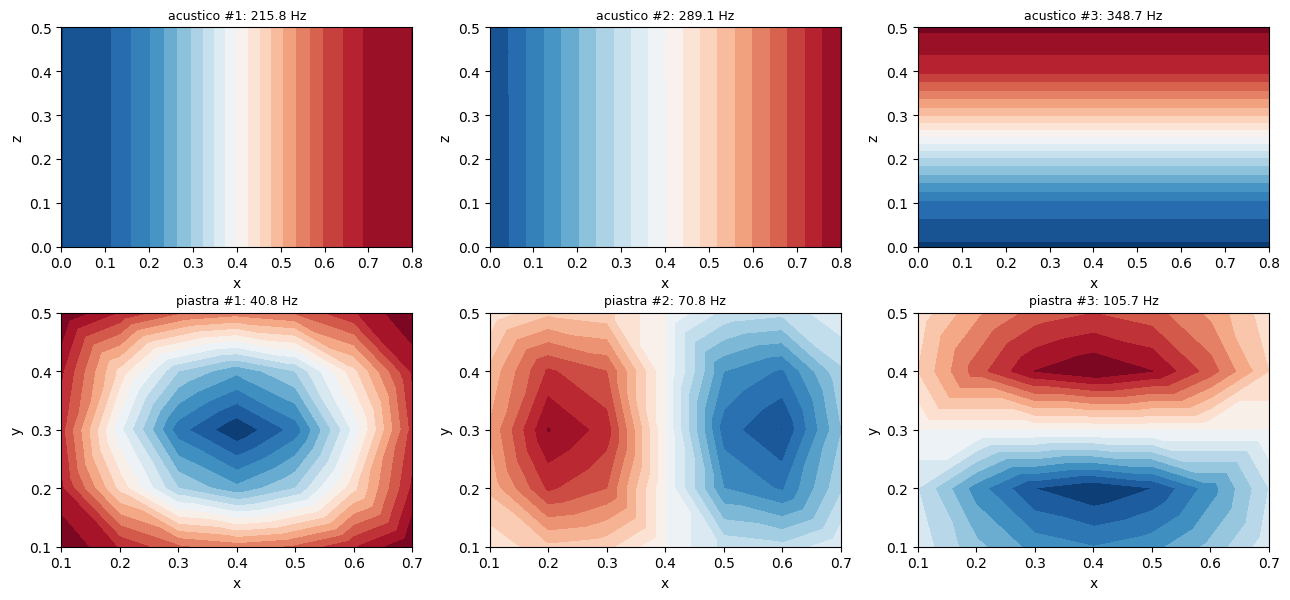

In [12]:
# forme modali: pressione sul piano medio y = Ly/2 e spostamento w della piastra
fig, axes = plt.subplots(2, 3, figsize=(13, 6))

order = np.argsort(vals)
w_dof = np.searchsorted(idx_free, node_of_dof[comp_of_dof == 2] * 6 + 2)
plate_nodes_w = node_of_dof[comp_of_dof == 2]

for k in range(3):
    ax = axes[0, k]
    p = modes_a[:, k]
    sel = np.abs(nodes[:, 1] - LY / 2) < 1e-9
    tp = ax.tricontourf(nodes[sel, 0], nodes[sel, 2], p[sel], levels=20,
                        cmap="RdBu_r")
    ax.set_title(f"acustico #{k+1}: {freqs_a[k]:.1f} Hz", fontsize=9)
    ax.set_aspect("equal"); ax.set_xlabel("x"); ax.set_ylabel("z")

    ax = axes[1, k]
    phi = vecs[:, order[k]]
    w = phi[w_dof]
    ax.tricontourf(nodes[plate_nodes_w, 0], nodes[plate_nodes_w, 1], w,
                   levels=20, cmap="RdBu_r")
    ax.set_title(f"piastra #{k+1}: {freqs_s[k]:.1f} Hz", fontsize=9)
    ax.set_aspect("equal"); ax.set_xlabel("x"); ax.set_ylabel("y")

plt.tight_layout()
plt.show()

### La cavità in 3D

I contour qui sopra sono un taglio sul piano y = Ly/2. Per vedere il modo in
volume conviene sfruttare il fatto che la mesh della scatola e' **strutturata**:
la pressione nodale si riporta su una griglia regolare, e da li' si interpola
dove serve.

In [13]:
# La mesh della scatola e' strutturata: si puo' riportare la pressione nodale
# su una griglia regolare (nx+1, ny+1, nz+1) e da li' fare tagli e isosuperfici.
def nodal_field_to_grid(nodes, values, tol=1e-6):
    """Riporta un campo nodale su griglia strutturata (xs, ys, zs, V)."""
    rc = np.round(nodes / tol) * tol            # toglie il rumore di gmsh
    xs, ys, zs = (np.unique(rc[:, d]) for d in range(3))
    ix = np.searchsorted(xs, rc[:, 0])
    iy = np.searchsorted(ys, rc[:, 1])
    iz = np.searchsorted(zs, rc[:, 2])
    V = np.full((xs.size, ys.size, zs.size), np.nan)
    V[ix, iy, iz] = values
    if np.isnan(V).any():
        raise ValueError("mesh non strutturata: griglia incompleta")
    return xs, ys, zs, V

xs, ys, zs, _ = nodal_field_to_grid(nodes, modes_a[:, 0])
print(f"griglia {xs.size} x {ys.size} x {zs.size} = {xs.size*ys.size*zs.size} nodi")

griglia 9 x 7 x 6 = 378 nodi


**Pareti della cavità colorate per pressione** (matplotlib, nessuna dipendenza
extra). Per una cavità a pareti rigide gli antinodi cadono sul contorno, quindi
il campo sulle pareti è già la firma del modo: si riconoscono a colpo d'occhio
gli indici (l, m, n).

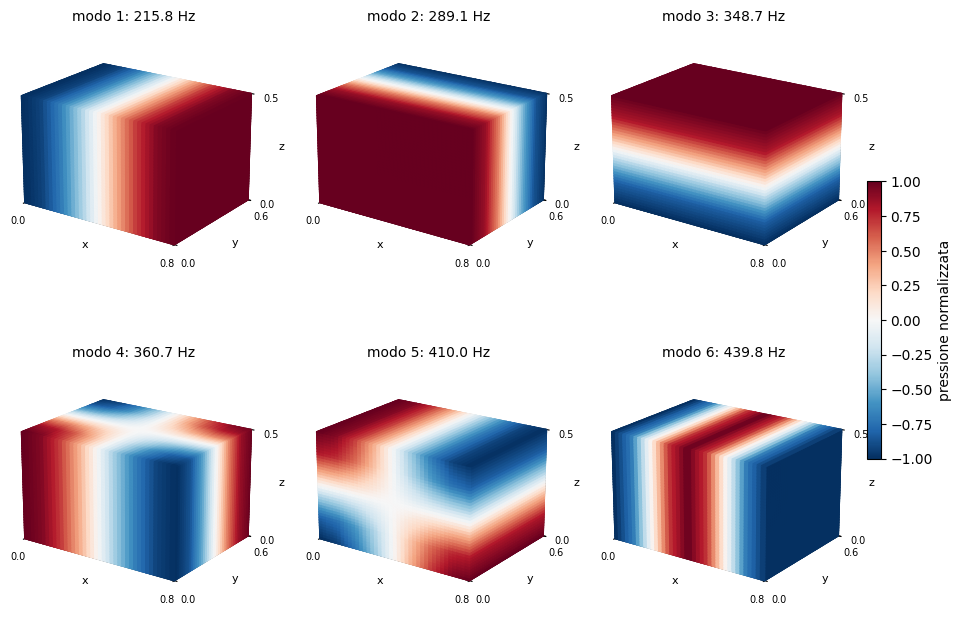

In [14]:
import itertools

from matplotlib.colors import Normalize
from scipy.interpolate import RegularGridInterpolator

def plot_cavity_mode(ax, p, n=40, cmap="RdBu_r"):
    """Pareti della cavita' colorate per pressione (interpolazione trilineare).

    Per un modo di cavita' rigida gli antinodi stanno sulle pareti, quindi il
    campo sul contorno e' gia' la firma del modo. La vista interattiva sotto
    mostra invece l'interno con le isosuperfici.
    """
    _, _, _, V = nodal_field_to_grid(nodes, p)
    V = V / np.abs(V).max()
    interp = RegularGridInterpolator((xs, ys, zs), V)
    norm, cm = Normalize(-1, 1), plt.get_cmap(cmap)

    u = {"x": np.linspace(xs[0], xs[-1], n),
         "y": np.linspace(ys[0], ys[-1], n),
         "z": np.linspace(zs[0], zs[-1], n)}
    for axis, side in itertools.product("xyz", (0, -1)):
        const = u[axis][side]
        d1, d2 = [k for k in "xyz" if k != axis]
        A, B = np.meshgrid(u[d1], u[d2], indexing="ij")
        pts = {axis: np.full_like(A, const), d1: A, d2: B}
        F = interp(np.stack([pts["x"], pts["y"], pts["z"]], axis=-1))
        ax.plot_surface(pts["x"], pts["y"], pts["z"], rstride=1, cstride=1,
                        facecolors=cm(norm(F)), shade=False)

    ax.set_xlim(0, LX); ax.set_ylim(0, LY); ax.set_zlim(0, LZ)
    ax.set_box_aspect((LX, LY, LZ))
    ax.set_xticks([0, LX]); ax.set_yticks([0, LY]); ax.set_zticks([0, LZ])
    ax.tick_params(labelsize=7, pad=0)
    ax.set_xlabel("x", fontsize=8, labelpad=-8)
    ax.set_ylabel("y", fontsize=8, labelpad=-8)
    ax.set_zlabel("z", fontsize=8, labelpad=-8)


fig = plt.figure(figsize=(13, 8))
for k in range(6):
    ax = fig.add_subplot(2, 3, k + 1, projection="3d")
    plot_cavity_mode(ax, modes_a[:, k])
    ax.view_init(elev=20, azim=-55)
    ax.set_title(f"modo {k+1}: {freqs_a[k]:.1f} Hz", fontsize=10)

fig.colorbar(plt.cm.ScalarMappable(norm=Normalize(-1, 1), cmap="RdBu_r"),
             ax=fig.axes, shrink=0.45, pad=0.02,
             label="pressione normalizzata")
plt.show()

**Vista interattiva con isosuperfici** (plotly, opzionale — `pip install
plotly`): mostra l'interno della cavità, ruotabile, con lo slider per passare
da un modo all'altro. Se plotly non è installato la cella stampa un avviso e
prosegue.

In [15]:
try:
    import plotly.graph_objects as go
except ImportError:
    print("plotly non installato: salta la vista interattiva "
          "(pip install plotly)")
else:
    Xg, Yg, Zg = np.meshgrid(xs, ys, zs, indexing="ij")
    flat = dict(x=Xg.ravel(), y=Yg.ravel(), z=Zg.ravel())

    fig = go.Figure()
    for k in range(6):
        _, _, _, V = nodal_field_to_grid(nodes, modes_a[:, k])
        V = V / np.abs(V).max()
        fig.add_trace(go.Isosurface(
            **flat, value=V.ravel(),
            isomin=-0.8, isomax=0.8, surface_count=7,
            colorscale="RdBu", reversescale=True, cmin=-1, cmax=1,
            opacity=0.35, caps=dict(x_show=False, y_show=False, z_show=False),
            visible=(k == 0), name=f"modo {k+1}",
        ))

    steps = [dict(method="update", label=f"{k+1}",
                  args=[{"visible": [i == k for i in range(6)]},
                        {"title": f"modo {k+1}: {freqs_a[k]:.1f} Hz"}])
             for k in range(6)]
    fig.update_layout(
        title=f"modo 1: {freqs_a[0]:.1f} Hz",
        sliders=[dict(active=0, currentvalue={"prefix": "modo acustico "},
                      steps=steps)],
        scene=dict(aspectmode="data", xaxis_title="x",
                   yaxis_title="y", zaxis_title="z"),
        width=780, height=560, margin=dict(l=0, r=0, t=40, b=0),
    )
    fig.show()

plotly non installato: salta la vista interattiva (pip install plotly)


## 6. Il cerchio è chiuso: `system["coupling"]`

Il posto vuoto è ora riempito. La matrice di accoppiamento è

$$\mathbf K_c = \int_S \mathbf N_s^{\mathsf T}\, \mathbf n\, \mathbf N_a\; dS,
\qquad \mathbf M_c = -\rho_0\, \mathbf K_c^{\mathsf T}$$

integrata sulle facce di interfaccia, con $\mathbf n$ **uscente dal fluido**
(orientata in automatico guardando l'esaedro dietro ogni faccia). Il sistema
accoppiato è quello non simmetrico della formulazione Euleriana $(w, p)$:

$$\begin{bmatrix}
\mathbf K_s - \omega^2 \mathbf M_s & -\mathbf K_c \\
-\rho_0\omega^2 \mathbf K_c^{\mathsf T} & \mathbf K_a - \omega^2 \mathbf M_a
\end{bmatrix}
\begin{Bmatrix} \mathbf w \\ \mathbf p \end{Bmatrix}
= \begin{Bmatrix} \mathbf F_s \\ \mathbf F_a \end{Bmatrix}$$

**Il seguito sta in [`vibroacoustic_box_plate.ipynb`](vibroacoustic_box_plate.ipynb)**,
sulla stessa identica geometria: modi accoppiati contro disaccoppiati,
confronto vincolo S-S-S-S contro C-C-C-C, risposta forzata e campo di
pressione 3D.

Un risultato in anticipo: l'aria sigillata nella cavità si comporta come una
molla e alza il primo modo della piastra da **40.84 a 43.46 Hz** (+6.4%),
in accordo entro lo 0.5% con la previsione di cavità compatta
$k = \rho_0 c_0^2 (\Delta V)^2 / V$.

**Sul solver non simmetrico**, previsto qui sopra: serve davvero `eigs` e non
`eigsh`, ma con una trappola in più. `eigs(K, M=M, sigma=...)` assume che `M`
sia **simmetrica definita positiva**, e la massa accoppiata
$\begin{bmatrix}\mathbf M_s & 0\\ \rho_0\mathbf K_c^{\mathsf T} &
\mathbf M_a\end{bmatrix}$ non lo è: ARPACK restituisce autovalori sbagliati
**senza segnalare nulla** (frequenze di pochi Hz al posto di 43 Hz). Per
questo `solve_vibroacoustic_modal` fa lo shift-invert a mano, con
`splu(K - σM)` dentro un `LinearOperator`.

Resta da fare: **PML**, per i problemi non confinati. Per la troncatura di un
dominio esterno c'è già la condizione anecoica di onda piana,
`AcousticBC.add_anechoic(...)` ($Z = \rho_0 c_0$).